# SessionSmith チュートリアル

このノートブックでは、SessionSmithの使い方を段階的に学びます。

## 目次

1. [SSM - Git風セッション管理（推奨）](#1-ssm---git風セッション管理推奨)
2. [チェックポイント（長時間学習対応）](#2-チェックポイント長時間学習対応)
3. [常時記録（クラッシュ対策）](#3-常時記録クラッシュ対策)
4. [形式変換（.pkl/.json互換）](#4-形式変換pkljson互換)
5. [基本的な保存・復元（レガシーAPI）](#5-基本的な保存復元レガシーapi)
6. [セッション情報・比較](#6-セッション情報比較)
7. [アルゴリズムトレーサー](#7-アルゴリズムトレーサー)
8. [クリーンアップ](#8-クリーンアップ)


---

## 1. SSM - Git風セッション管理（推奨）

SessionSmithの主要機能であるSSM（SessionSmith Manager）を使います。
`.ssm/` ディレクトリにGit風にセッションを管理します。


In [ ]:
# SessionSmithをインポート
import os

from SessionSmith import ssm

# 作業ディレクトリを準備
os.makedirs("temp", exist_ok=True)
os.chdir("temp")

print(f"作業ディレクトリ: {os.getcwd()}")


In [ ]:
# SSMを初期化（.ssm/ ディレクトリを作成）
ssm.init(force=True)  # force=True で既存の .ssm を上書き


In [ ]:
# 変数を作成
import numpy as np

model_name = "MyModel"
learning_rate = 0.001
epochs = 100
data = np.random.randn(100, 10)

print(f"model_name: {model_name}")
print(f"learning_rate: {learning_rate}")
print(f"epochs: {epochs}")
print(f"data shape: {data.shape}")


In [ ]:
# コミット
ssm.commit("Initial setup")


In [ ]:
# 変数を変更
learning_rate = 0.0001
epochs = 200
weights = np.random.randn(10, 5)

print("変数を変更しました")
print(f"learning_rate: {learning_rate}")
print(f"epochs: {epochs}")
print(f"weights shape: {weights.shape}")


In [ ]:
# 2回目のコミット
ssm.commit("Add weights, update hyperparams")


In [ ]:
# 履歴を確認
ssm.log()


In [ ]:
# 現在の状態を確認
ssm.status()


---

## 2. チェックポイント（長時間学習対応）

機械学習の学習ループなど、長時間実行されるタスクに最適です。
定期的に自動保存し、中断時にも状態を復元できます。


In [ ]:
import time

# 学習用の変数を準備
loss = 1.0
accuracy = 0.0
epoch = 0

print("チェックポイントのデモを開始します")
print("（2秒ごとに自動チェックポイント）")


In [ ]:
# チェックポイントを使用した学習シミュレーション
with ssm.checkpoint(interval=2, max_checkpoints=3) as cp:
    for epoch in range(10):
        # 学習をシミュレート
        loss = 1.0 / (epoch + 1)
        accuracy = 1.0 - loss

        # 手動チェックポイント + メトリクス記録
        cp.step(loss=loss, accuracy=accuracy, epoch=epoch)

        print(f"Epoch {epoch}: loss={loss:.4f}, accuracy={accuracy:.4f}")
        time.sleep(0.3)

print("\n学習完了！")


In [ ]:
# チェックポイント一覧を確認
checkpoints = ssm.list_checkpoints()
print(f"チェックポイント数: {len(checkpoints)}\n")

for i, cp in enumerate(checkpoints):
    print(f"[{i}] {cp['file']}")
    print(f"    Timestamp: {cp['timestamp']}")
    print(f"    Variables: {cp['variable_count']}")
    print()


In [ ]:
# 変数を変更してから復元
loss = 999
accuracy = -999
print(f"変更後: loss={loss}, accuracy={accuracy}")

# チェックポイントから復元
meta = ssm.restore_checkpoint()
print(f"\n復元後: loss={loss}, accuracy={accuracy}")


In [ ]:
# 古いチェックポイントを削除
ssm.clean_checkpoints(keep=1)  # 最新1つだけ保持


---

## 3. 常時記録（クラッシュ対策）

Jupyter Notebookがクラッシュした場合に備えて、セル実行ごとに自動保存します。


In [ ]:
# 常時記録を有効化
ssm.continuous(enable=True, verbose=True)

# このセルを実行すると自動保存される
important_data = {"key": "value", "number": 42}
result = [1, 2, 3, 4, 5]


In [ ]:
# 常時記録を無効化
ssm.continuous(enable=False)
print("クラッシュ後は ssm.recover() で復元できます")


---

## 4. 形式変換（.pkl/.json互換）

SSMのコミットを従来形式（`.pkl`、`.json`）でエクスポートしたり、
従来形式からインポートしたりできます。


In [ ]:
# 新しい変数を作成してコミット
export_data = {"name": "test", "values": [1, 2, 3]}
ssm.commit("Export test")

# pickle形式でエクスポート
ssm.export("export_backup.pkl")

# JSON形式でエクスポート
ssm.export("export_backup.json")


In [ ]:
# 形式変換（pickle → JSON）
ssm.convert("export_backup.pkl", "converted.json")

# 履歴を確認
ssm.log(oneline=True)


---

## 5. 基本的な保存・復元（レガシーAPI）

従来の`save_session`/`load_session` APIも引き続き使用できます。

> ⚠️ 新規開発では SSM の使用を推奨します。


In [ ]:
from SessionSmith import load_session, save_session

# 変数を作成
legacy_var = "Hello from legacy API"
legacy_list = [1, 2, 3, 4, 5]

# セッション保存
save_session("legacy_session.pkl", verbose=True)


In [ ]:
# 変数を削除して復元
del legacy_var, legacy_list

load_session("legacy_session.pkl", verbose=True)

print(f"legacy_var: {legacy_var}")
print(f"legacy_list: {legacy_list}")


---

## 6. セッション情報・比較


In [ ]:
from SessionSmith import get_session_info, print_session_info

# セッション情報を取得
print_session_info("legacy_session.pkl")


---

## 7. アルゴリズムトレーサー

アルゴリズムの実行を1行ごとにトレースし、可視化します。


In [ ]:
from SessionSmith import AlgorithmTracer, print_trace_summary


# バブルソートをトレース
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

# トレース対象の配列
arr = [64, 34, 25, 12, 22, 11, 90]
print(f"ソート前: {arr}")

# トレーサーを使用
with AlgorithmTracer(target_variables=["arr"]) as tracer:
    result = bubble_sort(arr.copy())

print(f"ソート後: {result}")
print(f"\nトレースポイント数: {len(tracer.get_trace_data())}")


---

## 8. クリーンアップ


In [ ]:
import shutil

# 作成したファイルを削除
for f in ["legacy_session.pkl", "export_backup.pkl", "export_backup.json", "converted.json"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"✓ {f} を削除")

# .ssm ディレクトリを削除
if os.path.exists(".ssm"):
    shutil.rmtree(".ssm")
    print("✓ .ssm/ を削除")

# 元のディレクトリに戻る
os.chdir("..")

# tempディレクトリを削除
if os.path.exists("temp"):
    shutil.rmtree("temp")
    print("✓ temp/ を削除")

print("\n✅ クリーンアップ完了！")


---

## まとめ

### SSM（推奨）
```python
from SessionSmith import ssm

ssm.init()                         # 初期化
ssm.commit("message")              # コミット
ssm.log()                          # 履歴
ssm.checkout("hash")               # 復元
ssm.continuous()                   # 常時記録
ssm.recover()                      # クラッシュ復元
```

### チェックポイント（長時間学習）
```python
with ssm.checkpoint(interval=300) as cp:
    for epoch in range(1000):
        loss = train()
        cp.step(loss=loss)

ssm.restore_checkpoint()           # 復元
ssm.list_checkpoints()             # 一覧
```

### 形式変換
```python
ssm.export("backup.pkl")           # エクスポート
ssm.import_session("old.pkl")      # インポート
ssm.convert("a.pkl", "b.json")     # 変換
```

### CLI
```bash
ssm init                           # 初期化
ssm commit -m "message"            # コミット
ssm log --oneline                  # 履歴
ssm watch --interval 10            # 監視
ssm dashboard                      # ダッシュボード
```


# SessionSmith チュートリアル

このノートブックでは、SessionSmithの使い方を段階的に学びます。

## 目次

1. [基本的な使い方](#1-基本的な使い方)
2. [圧縮サポート](#2-圧縮サポート)
3. [セッション情報表示](#3-セッション情報表示)
4. [セレクティブロード](#4-セレクティブロード)
5. [セッション比較](#5-セッション比較)
6. [SessionManagerクラス](#6-sessionmanagerクラス)
7. [自動バックアップ](#7-自動バックアップ)
8. [カスタムシリアライザー](#8-カスタムシリアライザー)
9. [実践例](#9-実践例)
10. [アルゴリズム実行トレーサー](#10-アルゴリズム実行トレーサー新機能)
11. [クリーンアップ](#11-クリーンアップ)



## 1. 基本的な使い方

まず、SessionSmithをインポートして、基本的な保存・復元の使い方を学びましょう。

**注意**: SessionSmithはJupyter Notebook環境で使用する場合、`_ih`, `_oh`, `In`, `Out`, `_i1`, `_i2`などの内部変数を自動的に除外します。これにより、不要な変数が保存されることを防ぎます。内部変数も保存したい場合は`exclude_jupyter=False`を指定してください。

チュートリアルで作成するファイルは`temp/`ディレクトリに保存されます。


In [1]:
# SessionSmithをインポート
import os

from SessionSmith import load_session, save_session

# tempディレクトリを作成（存在しない場合）
os.makedirs("temp", exist_ok=True)
print("✓ temp/ディレクトリを準備しました")

# いくつかの変数を作成
import numpy as np
import pandas as pd

# データを作成
data = {"name": "SessionSmith", "version": "0.1.1"}
numbers = [1, 2, 3, 4, 5]
array = np.array([1, 2, 3, 4, 5])
df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})

print("変数を作成しました:")
print(f"  data: {data}")
print(f"  numbers: {numbers}")
print(f"  array: {array}")
print(f"  df shape: {df.shape}")


✓ temp/ディレクトリを準備しました
変数を作成しました:
  data: {'name': 'SessionSmith', 'version': '0.1.1'}
  numbers: [1, 2, 3, 4, 5]
  array: [1 2 3 4 5]
  df shape: (3, 2)


In [2]:
# セッションを保存
save_session("temp/my_session.pkl", verbose=True)
print("\n✓ セッションを保存しました")

Saved variable: data (dict)
Saved variable: numbers (list)
Saved variable: array (ndarray)
Saved variable: df (DataFrame)
Session saved to temp/my_session.pkl (859 bytes)
Warnings: 3 variables could not be saved

✓ セッションを保存しました


In [3]:
# 変数を削除してから復元をテスト
del data, numbers, array, df

# セッションを復元
load_session("temp/my_session.pkl", verbose=True)

# 復元された変数を確認
print("\n復元された変数:")
print(f"  data: {data}")
print(f"  numbers: {numbers}")
print(f"  array: {array}")
print(f"  df shape: {df.shape}")


Loaded variable: data (dict)
Loaded variable: numbers (list)
Loaded variable: array (ndarray)
Loaded variable: df (DataFrame)
Loaded 4 variables

復元された変数:
  data: {'name': 'SessionSmith', 'version': '0.1.1'}
  numbers: [1, 2, 3, 4, 5]
  array: [1 2 3 4 5]
  df shape: (3, 2)


## 2. 圧縮サポート

大きなセッションを圧縮して保存することで、ディスク容量を節約できます。


In [4]:
# 大きなデータを作成
large_data = np.random.rand(1000, 1000)

# 通常の保存
save_session("temp/session_normal.pkl")
size_normal = os.path.getsize("temp/session_normal.pkl")

# gzip圧縮で保存
save_session("temp/session_gzip.pkl", compress=True)
size_gzip = os.path.getsize("temp/session_gzip.pkl")

# bzip2圧縮で保存
save_session("temp/session_bz2.pkl", compress="bz2")
size_bz2 = os.path.getsize("temp/session_bz2.pkl")

print(f"通常: {size_normal:,} bytes")
print(f"gzip: {size_gzip:,} bytes ({size_gzip/size_normal*100:.1f}%)")
print(f"bz2:  {size_bz2:,} bytes ({size_bz2/size_normal*100:.1f}%)")


通常: 8,000,962 bytes
gzip: 7,544,669 bytes (94.3%)
bz2:  7,637,833 bytes (95.5%)


In [5]:
# 圧縮されたファイルも自動的に検出してロードできます
del large_data
load_session("temp/session_gzip.pkl")
print(f"✓ gzip圧縮ファイルから復元: large_data shape = {large_data.shape}")


✓ gzip圧縮ファイルから復元: large_data shape = (1000, 1000)


## 3. セッション情報表示

保存されたセッションファイルの詳細情報を確認できます。


In [6]:
from SessionSmith import list_session_variables, print_session_info

# セッション情報を取得
info = get_session_info("temp/my_session.pkl")
print("セッション情報:")
print(f"  ファイルサイズ: {info['file_size']:,} bytes")
print(f"  変数の数: {info['variable_count']}")
print(f"  総データサイズ: {info['total_data_size']:,} bytes")
print(f"  圧縮形式: {info['compression'] or 'なし'}")


セッション情報:
  ファイルサイズ: 859 bytes
  変数の数: 4
  総データサイズ: 977 bytes
  圧縮形式: なし


In [7]:
# 整形して表示
print_session_info("temp/my_session.pkl")


Session File: temp/my_session.pkl
File Size: 859 bytes
Modified: 2025-12-20T18:47:59.548755
Variables: 4
Total Data Size: 977 bytes

Variables:
  array                (ndarray        ) - 188 bytes
  data                 (dict           ) - 56 bytes
  df                   (DataFrame      ) - 707 bytes
  numbers              (list           ) - 26 bytes


In [8]:
# 変数名のリストを取得
variables = list_session_variables("temp/my_session.pkl")
print(f"保存されている変数: {variables}")


保存されている変数: ['array', 'data', 'df', 'numbers']


## 4. セレクティブロード

特定の変数のみをロードしたり、特定の変数を除外してロードできます。


In [9]:
# 新しい変数空間を作成
import sys

test_globals = {}

# 特定の変数のみをロード
load_session("temp/my_session.pkl", globals_dict=test_globals, include=["data", "numbers"])
print("ロードされた変数:", list(test_globals.keys()))


ロードされた変数: ['data', 'numbers']


In [10]:
# 特定の変数を除外してロード
test_globals2 = {}
load_session("temp/my_session.pkl", globals_dict=test_globals2, exclude=["df"])
print("ロードされた変数（dfを除外）:", list(test_globals2.keys()))


ロードされた変数（dfを除外）: ['data', 'numbers', 'array']


## 5. セッション比較

2つのセッションファイルを比較して、違いを確認できます。


In [11]:
# 最初のセッションを作成
data1 = {"version": 1, "count": 10}
save_session("temp/session1.pkl", exclude=["data", "numbers", "array", "df", "large_data"])

# 2番目のセッションを作成（変数を追加・変更）
data2 = {"version": 2, "count": 20}
new_var = "新しい変数"
save_session("temp/session2.pkl", exclude=["data", "numbers", "array", "df", "large_data"])


In [12]:
from SessionSmith import compare_sessions, print_comparison

# セッションを比較
result = compare_sessions("temp/session1.pkl", "temp/session2.pkl", detailed=True)
print("比較結果:")
print(f"  共通変数: {len(result['common_variables'])}")
print(f"  追加された変数: {result['added_variables']}")
print(f"  削除された変数: {result['removed_variables']}")
if 'changed_variables' in result:
    print(f"  変更された変数: {result['changed_variables']}")


比較結果:
  共通変数: 8
  追加された変数: ['data2', 'new_var']
  削除された変数: []
  変更された変数: []


In [13]:
# 整形して表示
print_comparison("temp/session1.pkl", "temp/session2.pkl", detailed=True)


Comparison: temp/session1.pkl vs temp/session2.pkl

Common variables (8):
  data1
  info
  size_bz2
  size_gzip
  size_normal
  test_globals
  test_globals2
  variables

Added variables (2):
  + data2
  + new_var


## 6. SessionManagerクラス

SessionManagerクラスを使うと、より便利にセッションを管理できます。


In [14]:
from SessionSmith import SessionManager

# マネージャーを作成
manager = SessionManager()

# 現在の変数を確認（Jupyter内部変数や組み込み関数を除外）
variables = manager.list_variables()
print(f"現在の変数 ({len(variables)}個):")
for var in variables[:10]:  # 最初の10個を表示
    print(f"  - {var}")
if len(variables) > 10:
    print(f"  ... 他 {len(variables) - 10}個の変数")


現在の変数 (30個):
  - SessionManager
  - array
  - compare_sessions
  - data
  - data1
  - data2
  - df
  - get_ipython
  - get_session_info
  - info
  ... 他 20個の変数


In [15]:
# マネージャーを使って保存
manager.save("temp/managed_session.pkl", metadata=True, verbose=True)


Saved variable: data (dict)
Saved variable: numbers (list)
Saved variable: array (ndarray)
Saved variable: df (DataFrame)
Saved variable: size_normal (int)
Saved variable: size_gzip (int)
Saved variable: size_bz2 (int)
Saved variable: large_data (ndarray)
Saved variable: info (dict)
Saved variable: variables (list)
Saved variable: test_globals (dict)
Saved variable: test_globals2 (dict)
Saved variable: data1 (dict)
Saved variable: data2 (dict)
Saved variable: new_var (str)
Saved variable: result (dict)
Saved variable: var (str)
Session saved to temp/managed_session.pkl (8002285 bytes)
Warnings: 4 variables could not be saved


In [16]:
# マネージャーを使ってロード
new_vars = manager.load("temp/managed_session.pkl", verbose=True)
print(f"\n✓ {len(new_vars)}個の変数がロードされました")


Session metadata: {'version': '0.1.1', 'saved_at': '2025-12-20T18:48:00.328242', 'variable_count': 17}
Loaded variable: data (dict)
Loaded variable: numbers (list)
Loaded variable: array (ndarray)
Loaded variable: df (DataFrame)
Loaded variable: size_normal (int)
Loaded variable: size_gzip (int)
Loaded variable: size_bz2 (int)
Loaded variable: large_data (ndarray)
Loaded variable: info (dict)
Loaded variable: variables (list)
Loaded variable: test_globals (dict)
Loaded variable: test_globals2 (dict)
Loaded variable: data1 (dict)
Loaded variable: data2 (dict)
Loaded variable: new_var (str)
Loaded variable: result (dict)
Loaded variable: var (str)
Loaded 17 variables

✓ 17個の変数がロードされました


## 7. 自動バックアップ

長時間実行する処理では、自動バックアップが便利です。


In [17]:
# 自動バックアップを開始（10秒ごと - デモ用）
# 実際の使用では、300秒（5分）などに設定することをお勧めします
manager.auto_save(interval=10, file_path="temp/autosave.pkl", metadata=True)
print("✓ 自動バックアップを開始しました（10秒ごと）")
print(f"  実行中: {manager.is_auto_save_running()}")


✓ 自動バックアップを開始しました（10秒ごと）
  実行中: True


In [18]:
import time

# 少し待機（実際の処理をシミュレート）
print("処理を実行中...")
for i in range(3):
    time.sleep(2)
    print(f"  ステップ {i+1}/3 完了")

print("\n自動バックアップが動作していることを確認:")
print(f"  実行中: {manager.is_auto_save_running()}")


処理を実行中...
  ステップ 1/3 完了
  ステップ 2/3 完了
  ステップ 3/3 完了

自動バックアップが動作していることを確認:
  実行中: True


In [19]:
# 自動バックアップを停止
manager.stop_auto_save()
print("✓ 自動バックアップを停止しました")
print(f"  実行中: {manager.is_auto_save_running()}")

# バックアップファイルが作成されているか確認
if os.path.exists("temp/autosave.pkl"):
    size = os.path.getsize("temp/autosave.pkl")
    print(f"  バックアップファイルサイズ: {size:,} bytes")


✓ 自動バックアップを停止しました
  実行中: False
  バックアップファイルサイズ: 8,002,552 bytes


## 8. カスタムシリアライザー

特定の型に対してカスタムシリアライゼーションを定義できます。


In [20]:
from SessionSmith import CustomSerializer


# カスタムクラスを定義
class MyCustomClass:
    def __init__(self, value):
        self.value = value
        self.timestamp = time.time()

    def to_dict(self):
        return {"value": self.value, "timestamp": self.timestamp}

    @classmethod
    def from_dict(cls, data):
        obj = cls(data["value"])
        obj.timestamp = data["timestamp"]
        return obj

# カスタムシリアライザーを作成
serializer = CustomSerializer()

# シリアライザーを登録
def my_serializer(obj):
    return obj.to_dict()

serializer.register(MyCustomClass, my_serializer)

# カスタムオブジェクトを作成
custom_obj = MyCustomClass(42)
print(f"カスタムオブジェクト: value={custom_obj.value}, timestamp={custom_obj.timestamp}")


カスタムオブジェクト: value=42, timestamp=1766224087.391912


In [21]:
# カスタムシリアライザーを使って保存
save_session("temp/custom_session.pkl", serializer=serializer, verbose=True)


Saved variable: data (dict)
Saved variable: numbers (list)
Saved variable: array (ndarray)
Saved variable: df (DataFrame)
Saved variable: size_normal (int)
Saved variable: size_gzip (int)
Saved variable: size_bz2 (int)
Saved variable: large_data (ndarray)
Saved variable: info (dict)
Saved variable: variables (list)
Saved variable: test_globals (dict)
Saved variable: test_globals2 (dict)
Saved variable: data1 (dict)
Saved variable: data2 (dict)
Saved variable: new_var (str)
Saved variable: result (dict)
Saved variable: var (str)
Saved variable: new_vars (dict)
Saved variable: i (int)
Saved variable: size (int)
Saved variable: serializer (CustomSerializer)
Saved variable: custom_obj (dict)
Session saved to temp/custom_session.pkl (8002656 bytes)
Warnings: 4 variables could not be saved


## 9. 実践例

実際の使用例として、機械学習モデルのセッションを保存・復元する例を示します。


In [22]:
# 機械学習の例（シミュレーション）
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# データを生成
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# モデルを訓練
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# スコアを計算
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"訓練スコア: {train_score:.4f}")
print(f"テストスコア: {test_score:.4f}")

# セッションを保存（モデル、データ、スコアを含む）
save_session("temp/ml_session.pkl", metadata=True, compress=True, verbose=True)


訓練スコア: 1.0000
テストスコア: 0.9000
Saved variable: data (dict)
Saved variable: numbers (list)
Saved variable: array (ndarray)
Saved variable: df (DataFrame)
Saved variable: size_normal (int)
Saved variable: size_gzip (int)
Saved variable: size_bz2 (int)
Saved variable: large_data (ndarray)
Saved variable: info (dict)
Saved variable: variables (list)
Saved variable: test_globals (dict)
Saved variable: test_globals2 (dict)
Saved variable: data1 (dict)
Saved variable: data2 (dict)
Saved variable: new_var (str)
Saved variable: result (dict)
Saved variable: var (str)
Saved variable: new_vars (dict)
Saved variable: i (int)
Saved variable: size (int)
Saved variable: serializer (CustomSerializer)
Saved variable: custom_obj (MyCustomClass)
Saved variable: X (ndarray)
Saved variable: y (ndarray)
Saved variable: X_train (ndarray)
Saved variable: X_test (ndarray)
Saved variable: y_train (ndarray)
Saved variable: y_test (ndarray)
Saved variable: model (RandomForestClassifier)
Saved variable: train_score 

In [23]:
# セッション情報を確認
print_session_info("temp/ml_session.pkl")

Session File: temp/ml_session.pkl
File Size: 8,056,334 bytes
Compression: gzip
Modified: 2025-12-20T18:48:08.604052
Variables: 31
Total Data Size: 17,400,321 bytes

Metadata:
  version: 0.1.1
  saved_at: 2025-12-20T18:48:08.212790
  variable_count: 31

Variables:
  X                    (ndarray        ) - 160,163 bytes
  X_test               (ndarray        ) - 32,153 bytes
  X_train              (ndarray        ) - 128,163 bytes
  array                (ndarray        ) - 188 bytes
  custom_obj           (MyCustomClass  ) - 80 bytes
  data                 (dict           ) - 56 bytes
  data1                (dict           ) - 38 bytes
  data2                (dict           ) - 38 bytes
  df                   (DataFrame      ) - 707 bytes
  i                    (int            ) - 5 bytes
  info                 (dict           ) - 323 bytes
  large_data           (ndarray        ) - 8,000,164 bytes
  model                (RandomForestClassifier) - 1,058,227 bytes
  new_var              

In [24]:
# セッション検証
from SessionSmith import verify_session

is_valid, error = verify_session("temp/ml_session.pkl")
if is_valid:
    print("✓ セッションファイルは有効です")
else:
    print(f"✗ エラー: {error}")


✓ セッションファイルは有効です


## 10. アルゴリズム実行トレーサー（新機能）

アルゴリズムの実行を1行ごとにトレースし、変数の状態を記録・可視化する機能です。ヒープソートやバブルソートなどのアルゴリズムの動作を理解するのに最適です。

**注意**: 可視化機能を使用するには`matplotlib`が必要です。インストールされていない場合は、トレースデータの保存とサマリー表示のみが可能です。

```bash
pip install matplotlib
# または
pip install SessionSmith[visualization]
```


In [25]:
from SessionSmith import AlgorithmTracer, visualize_algorithm_trace


# バブルソートの実装
def bubble_sort(arr):
    """バブルソートの実装"""
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]

# テスト用の配列
arr = [64, 34, 25, 12, 22, 11, 90]
print(f"ソート前: {arr}")

# トレーサーを使用して実行
with AlgorithmTracer(target_variables=["arr", "i", "j"], track_all=False) as tracer:
    bubble_sort(arr)

print(f"ソート後: {arr}")
print(f"✓ トレース完了: {len(tracer.get_trace_data())} ステップ記録")


ソート前: [64, 34, 25, 12, 22, 11, 90]
ソート後: [11, 12, 22, 25, 34, 64, 90]
✓ トレース完了: 75 ステップ記録


In [26]:
# トレースデータを保存
tracer.save("temp/bubble_sort_trace.json", format="json")
print("✓ トレースデータを保存しました: temp/bubble_sort_trace.json")

# サマリーを表示
print_trace_summary(trace_data=tracer.get_trace_data())


✓ トレースデータを保存しました: temp/bubble_sort_trace.json
トレースサマリー
総ステップ数: 75
追跡された変数: 3
  変数リスト: arr, i, j
行番号範囲: 6 - 236
実行された関数: __exit__, bubble_sort, stop


デバッグ: 最初のステップの変数: ['arr', 'i']
デバッグ: 変数 'arr' の型: list, 値: [64, 34, 25, 12, 22, 11, 90]
デバッグ: 変数 'arr' をリストとして検出（長さ: 7）
Animation saved to temp/bubble_sort_animation.gif
✓ アニメーションを保存しました: temp/bubble_sort_animation.gif


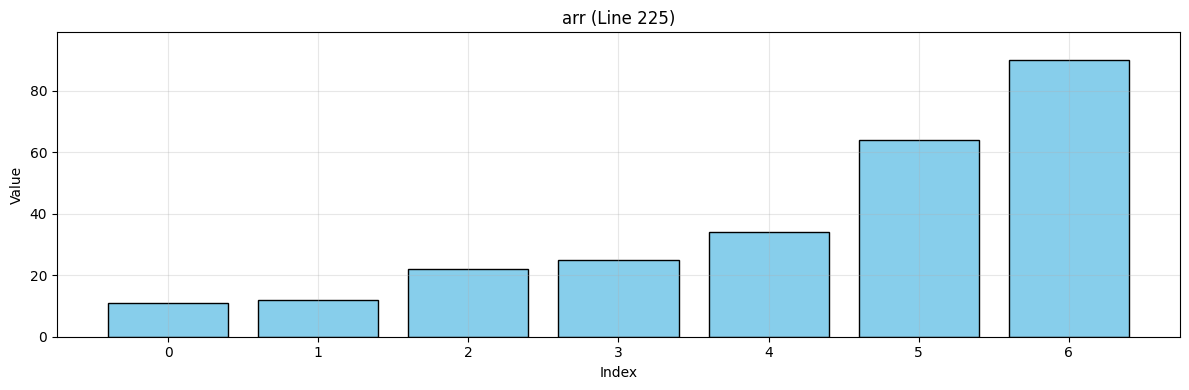

In [27]:
# 可視化（matplotlibがインストールされている場合）
try:
    visualize_algorithm_trace(
        trace_data=tracer.get_trace_data(),
        output_file="temp/bubble_sort_animation.gif",
        target_variables=["arr"],
        animation=True,
        show=False
    )
    print("✓ アニメーションを保存しました: temp/bubble_sort_animation.gif")
except ImportError:
    print("matplotlibがインストールされていないため、可視化をスキップします")
    print("インストール: pip install matplotlib")
except Exception as e:
    print(f"可視化中にエラーが発生しました: {e}")


In [28]:
# ヒープソートの例
def heap_sort(arr):
    """ヒープソートの実装"""
    n = len(arr)

    # ヒープを構築
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)

    # ヒープから要素を1つずつ取り出す
    for i in range(n - 1, 0, -1):
        arr[i], arr[0] = arr[0], arr[i]  # ルートと最後の要素を交換
        heapify(arr, i, 0)

def heapify(arr, n, i):
    """ヒープを構築する補助関数"""
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

# ヒープソートをトレース
arr2 = [12, 11, 13, 5, 6, 7]
print(f"ソート前: {arr2}")

with AlgorithmTracer(target_variables=["arr", "n", "i", "largest"], track_all=False) as tracer2:
    heap_sort(arr2)

print(f"ソート後: {arr2}")

# トレースデータを保存
tracer2.save("temp/heap_sort_trace.json", format="json")
print(f"✓ トレース完了: {len(tracer2.get_trace_data())} ステップ記録")
print("✓ トレースデータを保存しました: temp/heap_sort_trace.json")


ソート前: [12, 11, 13, 5, 6, 7]
ソート後: [5, 6, 7, 11, 12, 13]
✓ トレース完了: 122 ステップ記録
✓ トレースデータを保存しました: temp/heap_sort_trace.json


In [29]:
# サマリーを表示
summary = tracer2.get_summary()
print("トレースサマリー:")
print(f"  総ステップ数: {summary['total_steps']}")
print(f"  追跡された変数: {summary['variables_tracked']}")
if summary['line_range']:
    print(f"  行番号範囲: {summary['line_range'][0]} - {summary['line_range'][1]}")
if summary['functions_called']:
    print(f"  実行された関数: {', '.join(summary['functions_called'])}")


トレースサマリー:
  総ステップ数: 122
  追跡された変数: ['arr', 'i', 'largest', 'n']
  行番号範囲: 4 - 236
  実行された関数: heap_sort, __exit__, heapify, stop


In [30]:
# 作成したファイルを削除
files_to_remove = [
    "temp/my_session.pkl",
    "temp/session_normal.pkl",
    "temp/session_gzip.pkl",
    "temp/session_bz2.pkl",
    "temp/session1.pkl",
    "temp/session2.pkl",
    "temp/managed_session.pkl",
    "temp/autosave.pkl",
    "temp/custom_session.pkl",
    "temp/ml_session.pkl",
    "temp/bubble_sort_trace.json",
    "temp/bubble_sort_animation.gif",
    "temp/heap_sort_trace.json",
]

for file in files_to_remove:
    if os.path.exists(file):
        os.remove(file)
        print(f"✓ 削除: {file}")

# tempディレクトリが空になったら削除
try:
    if os.path.exists("temp") and not os.listdir("temp"):
        os.rmdir("temp")
        print("✓ temp/ディレクトリを削除しました")
except OSError:
    pass

print("\n✓ クリーンアップ完了！")


✓ 削除: temp/my_session.pkl
✓ 削除: temp/session_normal.pkl
✓ 削除: temp/session_gzip.pkl
✓ 削除: temp/session_bz2.pkl
✓ 削除: temp/session1.pkl
✓ 削除: temp/session2.pkl
✓ 削除: temp/managed_session.pkl
✓ 削除: temp/autosave.pkl
✓ 削除: temp/custom_session.pkl
✓ 削除: temp/ml_session.pkl
✓ 削除: temp/bubble_sort_trace.json
✓ 削除: temp/bubble_sort_animation.gif
✓ 削除: temp/heap_sort_trace.json
✓ temp/ディレクトリを削除しました

✓ クリーンアップ完了！


## 11. クリーンアップ


## 12. SSM（Git風セッション管理）

v0.1.8で追加された新しい機能です。`.ssm/`ディレクトリベースでセッションをGitのように管理できます。


In [ ]:
# SSMをインポート
import os
import tempfile

from SessionSmith import ssm

# 一時ディレクトリでテスト
test_dir = tempfile.mkdtemp()
print(f"テストディレクトリ: {test_dir}")

# 初期化
ssm.init(test_dir)
print("✓ SSM初期化完了")
print(f"  .ssmディレクトリ: {os.path.exists(os.path.join(test_dir, '.ssm'))}")


In [ ]:
# SSMクラスを直接使用（globals_dictを明示的に渡すため）
from SessionSmith.ssm import SSM

# テスト用変数を作成
test_vars = {"test_x": 100, "test_y": "Hello SSM", "test_data": [1, 2, 3, 4, 5]}

# SSMインスタンスを作成
test_ssm = SSM(path=test_dir, globals_dict=test_vars)

# コミット
commit_hash = test_ssm.commit("Initial commit")
print(f"✓ コミット成功: {commit_hash}")

# 変数を変更して2回目のコミット
test_vars["test_x"] = 200
test_vars["test_data"].append(6)
commit_hash2 = test_ssm.commit("Update values")
print(f"✓ 2回目のコミット: {commit_hash2}")


In [ ]:
# ログを表示
logs = test_ssm.log()
print("コミット履歴:")
for entry in logs:
    print(f"  {entry['hash'][:7]} - {entry['message']} ({entry['variable_count']}変数)")

# ステータスを確認
status = test_ssm.status()
print(f"\n現在のHEAD: {status['head'][:7] if status['head'] else 'なし'}")
print(f"コミット数: {status['commit_count']}")


In [ ]:
# 最初のコミットに戻る
print(f"現在のtest_x: {test_vars['test_x']}")
print(f"現在のtest_data: {test_vars['test_data']}")

# チェックアウト
test_ssm.checkout(commit_hash)
print(f"\n✓ チェックアウト完了: {commit_hash[:7]}")
print(f"復元後のtest_x: {test_vars['test_x']}")
print(f"復元後のtest_data: {test_vars['test_data']}")


In [ ]:
# クリーンアップ
import shutil

shutil.rmtree(test_dir)
print(f"✓ テストディレクトリを削除: {test_dir}")
print("\n✅ SSM機能の検証完了！")


### SessionManager の非推奨警告確認

`SessionManager` の `enable_version_control` パラメータは非推奨になりました。


In [ ]:
import warnings

# 非推奨警告を表示
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    from SessionSmith import SessionManager
    sm = SessionManager(enable_version_control=True)

    if w and issubclass(w[-1].category, DeprecationWarning):
        print("⚠️ 非推奨警告が表示されました:")
        print(f"   {w[-1].message}")
    else:
        print("❌ 警告なし（想定外）")

print("\n推奨される方法:")
print("  from SessionSmith import ssm")
print("  ssm.init()")
print("  ssm.commit('message')")


## まとめ

このチュートリアルでは、SessionSmithの主要な機能を学びました：

- ✅ 基本的な保存・復元
- ✅ 圧縮サポート
- ✅ セッション情報表示
- ✅ セレクティブロード
- ✅ セッション比較
- ✅ SessionManagerクラス
- ✅ 自動バックアップ
- ✅ カスタムシリアライザー
- ✅ 実践的な使用例
- ✅ アルゴリズム実行トレーサー
- ✅ **SSM（Git風セッション管理）** ← NEW in v0.1.8

詳細なドキュメントは [README.md](readme.md) を参照してください。
